## GLMsingle script

make sure that every regresssor has a one 1 entry in the design matrix! (`np.mean(np.sum(dm, axis=0))==1` !)

In [1]:
from glmsingle.glmsingle import GLM_single
import argparse
import os
import os.path as op
from nilearn import image
#from neural_priors.utils.data import Subject
from nilearn.glm.first_level import make_first_level_design_matrix
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
subject = '05'
session = 1
task = 'chase'
space = 'T1w'
bids_folder = '/shares/zne.uzh/mrenke/ds-asd'

TR = 2.33384 # TR from sub-01 task_bolc.json
runs = range(1,10)
stim_duration = 0.6

In [36]:
def get_fmri_events(subject, session=1,task='chase', bids_folder=None, runs=range(1,10)):
    behavior = []
    for run in runs:
        data = pd.read_table(op.join(bids_folder, f'sub-{subject}/ses-{session}/func/sub-{subject}_ses-{session}_task-{task}_run-{run}_events.tsv'))
        data['trial_nr'] = data['trial_nr'] + 40 * (run - 1)  # Adjust trial numbers to be unique across runs
        behavior.append(data)

    behavior = pd.concat(behavior, keys=runs, names=['run'])
    behavior = behavior.reset_index().set_index(['run', 'trial_type'])
    fixations = behavior.xs('fixation', 0, 'trial_type')
    fixations['trial_type'] = fixations.trial_nr.map(lambda trial_nr: f'fixation_{trial_nr}')
    choices = behavior.xs('choice', 0, 'trial_type')
    choices['trial_type'] = choices.trial_nr.map(lambda trial_nr: f'choice_{trial_nr}')
    responses = behavior.xs('response', 0, 'trial_type')
    responses['trial_type'] = responses.trial_nr.map(lambda trial_nr: f'response_{trial_nr}')
    feedbacks = behavior.xs('feedback', 0, 'trial_type')
    feedbacks['trial_type'] = feedbacks.trial_nr.map(lambda trial_nr: f'feedback_{trial_nr}')

    #events = pd.concat([fixations, choices, responses, feedbacks], axis=0).sort_values(['run', 'onset'])
    events = pd.concat([choices, feedbacks], axis=0).sort_values(['run', 'onset'])
    events = events[['onset', 'duration', 'trial_type']]  

    return events

In [37]:
def load_fmri_data(subject, session=1, task='chase', bids_folder=None, runs=range(1,10), space='T1w'):
    import nibabel as nib
    base = op.join(bids_folder, 'derivatives', 'fmriprep',f'sub-{subject}', f'ses-{session}', 'func')

    im_data = []
    for run in runs:
        fn = op.join(base, f'sub-{subject}_ses-{session}_task-{task}_run-{run}_space-{space}_desc-preproc_bold.nii.gz')
        im_data.append(nib.load(fn).get_fdata())

    return im_data

In [43]:
im_data = load_fmri_data(subject,   session, bids_folder=bids_folder, runs=runs) # for every run (9x): (49, 60, 45, 186)
print(np.shape(im_data)) # 186 timepoints/volumes per run

(9, 48, 61, 47, 129)


In [54]:
onsets = get_fmri_events(subject, session, bids_folder=bids_folder, runs=runs)
onsets['duration'] = stim_duration
onsets.head()

,onset,duration,trial_type
run,,,
1,1.268414,1,choice_1
1,5.088664,1,feedback_1
1,10.009840,1,choice_2
1,14.814368,1,feedback_2
1,18.400943,1,choice_3


In [55]:
tr = TR
N_volumes = np.shape(im_data)[-1] #186 #np.shape(im_data)[-1] # number of volumes per run
frametimes = np.linspace(tr/2., (N_volumes - .5)*tr, N_volumes)
onsets['onset'] = ((onsets['onset']+tr/2.) // tr) * tr

In [56]:
dm = [make_first_level_design_matrix(frametimes, onsets.loc[run], hrf_model='fir', oversampling=100.,
                                        drift_order=0,
                                        drift_model=None).drop('constant', axis=1) for run in runs]
dm = pd.concat(dm, keys=runs, names=['run']).fillna(0) # keys = range(1, 7)
dm.columns = [c.replace('_delay_0', '') for c in dm.columns]
dm /= dm.max()
dm[dm < 1.0] = 0.0
X = [dm.loc[run].values for run in runs]

In [ ]:
stim_duration = 1

derivatives = op.join(bids_folder, 'derivatives')
subject = f'{int(subject):02d}'

key = f'glm_stim.denoise'
base_dir = op.join(derivatives, key, f'sub-{subject}', f'ses-{session}', 'func')


In [57]:
print("Design matrix and data shapes:")
print(np.shape(X))
print(np.shape(im_data)) # 186 timepoints/volumes per run

Design matrix and data shapes:
(9, 129, 720)
(9, 48, 61, 47, 129)


In [58]:
# set options for GLM-single
opt = dict()
opt['wantlibrary'] = 1 # set important fields for completeness (but these would be enabled by default)
opt['wantglmdenoise'] = 1
opt['wantfracridge'] = 1
opt['wantfileoutputs'] = [0, 0, 0, 1] # keep the relevant outputs in memory and also save them to the disk

glmsingle_obj = GLM_single(opt)
results_glmsingle = glmsingle_obj.fit(
    X,
    im_data,
    stim_duration,
    tr,
    outputdir=base_dir,
    figuredir = op.join(base_dir, 'GLMestimatesingletrialfigures') # would be written to cwd otherwise and could crash when multiple nodes use it a the same time 
    )

# Save results: separate n1 and n2 betas
betas = results_glmsingle['typed']['betasmd']


*** FITTING TYPE-A MODEL (ONOFF) ***

fitting model...
done.

preparing output...
done.

computing model fits...
done.

computing R^2...
done.

computing SNR...
done.

*** Setting brain R2 threshold to 0.32427972141556743 ***

*** FITTING TYPE-B MODEL (FITHRF) ***



chunks: 100%|██████████| 3/3 [03:12<00:00, 64.29s/it]


*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



chunks: 100%|██████████| 3/3 [05:13<00:00, 104.59s/it]



*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 3/3 [00:33<00:00, 11.21s/it]


*** FITTING TYPE-D MODEL (GLMDENOISE_RR) ***



chunks: 100%|██████████| 3/3 [09:44<00:00, 194.95s/it]



*** Saving results to /shares/zne.uzh/mrenke/ds-asd/derivatives/glm_stim.denoise/sub-05/ses-1/func/TYPED_FITHRF_GLMDENOISE_RR.npy. ***

*** All model types done ***

*** return model types in results ***



In [60]:
base = op.join(bids_folder, 'derivatives', 'fmriprep',f'sub-{subject}', f'ses-{session}', 'func')
example_image = op.join(base, f'sub-{subject}_ses-{session}_task-{task}_run-1_space-{space}_desc-preproc_bold.nii.gz')
betas = image.new_img_like(example_image, betas)
    
# s1 - choice
betas_s1 = image.index_img(betas, slice(0, None, 2) ) # slice(0, None, 2) where to start, where to end, step size
betas_s1.to_filename(op.join(base_dir, f'sub-{subject}_ses-{session}_task-{task}_space-{space}_desc-s1-choices_pe.nii.gz'))
# s2 - feedback
betas_s2 = image.index_img(betas, slice(1, None, 2) ) # slice(0, None, 2) where to start, where to end, step size
betas_s2.to_filename(op.join(base_dir, f'sub-{subject}_ses-{session}_task-{task}_space-{space}_desc-s2-feedback_pe.nii.gz'))


## Inspect results

In [8]:
import nibabel as nib
derivatives = op.join(bids_folder, 'derivatives')
subject = f'{int(subject):02d}'
key = f'glm_stim.denoise'
base_dir = op.join(derivatives, key, f'sub-{subject}', f'ses-{session}', 'func')

betas_s1 = nib.load(op.join(base_dir, f'sub-{subject}_ses-{session}_task-{task}_space-{space}_desc-s1-choices_pe.nii.gz'))#.get_fdata()
betas_s2 = nib.load(op.join(base_dir, f'sub-{subject}_ses-{session}_task-{task}_space-{space}_desc-s2-feedback_pe.nii.gz'))#.get_fdata()

In [45]:
from nilearn import surface

surf_mesh_pati = op.join(derivatives, 'freesurfer', f'sub-{subject}', 'surf')
surf_mesh_fn = op.join(surf_mesh_pati, 'lh.pial')
surf_inner_mesh_fn = op.join(surf_mesh_pati, 'lh.white')

mask_img = op.join(bids_folder, 'derivatives', 'fmriprep',f'sub-{subject}', f'ses-{session}', 'func', f'sub-{subject}_ses-{session}_task-{task}_run-1_space-{space}_desc-brain_mask.nii.gz')

betas_surf_lh = surface.vol_to_surf(betas_s2,surf_mesh_fn, interpolation='nearest',inner_mesh = surf_inner_mesh_fn,
                                         mask_img = mask_img)

In [46]:
av_betas_surf_lh = np.mean(betas_surf_lh, axis=1)
av_betas_surf_lh.shape

(150767,)

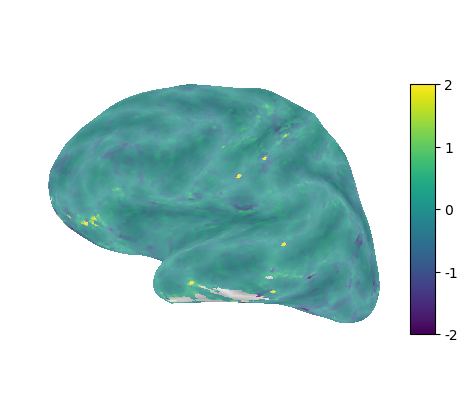

In [47]:
import nilearn.plotting as nplt

bg_map  = op.join(derivatives, 'freesurfer', f'sub-{subject}', 'surf', 'lh.sulc')
surf_mesh_inflated = op.join(surf_mesh_pati, 'lh.inflated')

threshold = 2
nplt.plot_surf(surf_map = av_betas_surf_lh, hemi='left', view='lateral', surf_mesh = surf_mesh_inflated,
                vmin= -threshold, vmax=threshold,
                bg_map=bg_map, bg_on_data=True,darkness=0.7)
plt.show()

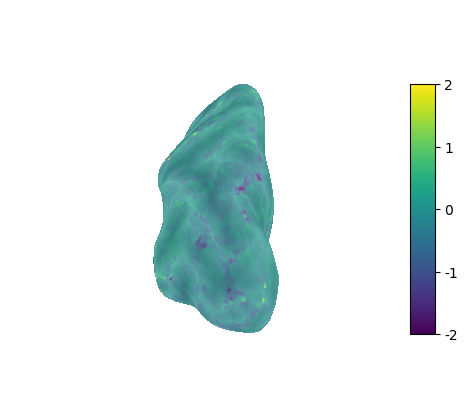

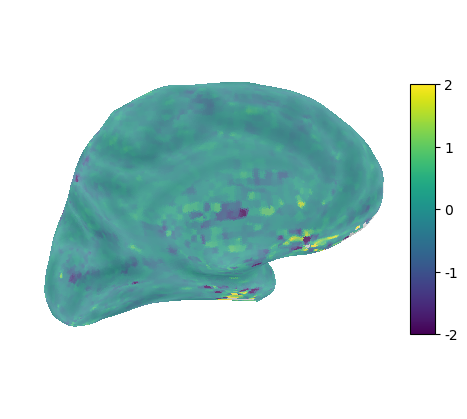

In [48]:
nplt.plot_surf(surf_map = av_betas_surf_lh, hemi='left', view='posterior', surf_mesh = surf_mesh_inflated,
                vmin= -threshold, vmax=threshold,
                bg_map=bg_map, bg_on_data=True,darkness=0.7)
nplt.plot_surf(surf_map = av_betas_surf_lh, hemi='left', view='medial', surf_mesh = surf_mesh_inflated,
                vmin= -threshold, vmax=threshold,
                bg_map=bg_map, bg_on_data=True,darkness=0.7)
plt.show()

## Inspect

<Axes: >

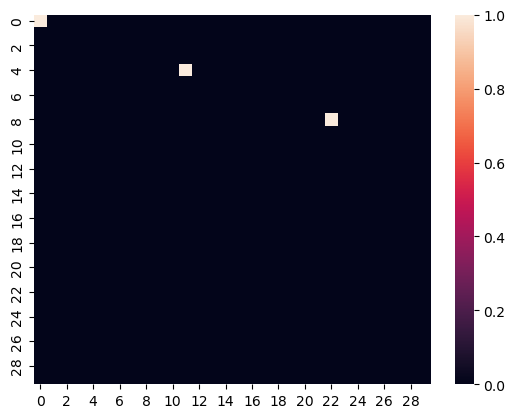

In [56]:
import seaborn as sns

sns.heatmap(X[0][:30,:30])

In [43]:
dm

choice_1  choice_10  choice_11  choice_12  choice_13  \
run                                                                   
1   1.16692         1.0        0.0        0.0        0.0        0.0   
    3.50076         0.0        0.0        0.0        0.0        0.0   
    5.83460         0.0        0.0        0.0        0.0        0.0   
    8.16844         0.0        0.0        0.0        0.0        0.0   
    10.50228        0.0        0.0        0.0        0.0        0.0   
...                 ...        ...        ...        ...        ...   
6   423.59196       0.0        0.0        0.0        0.0        0.0   
    425.92580       0.0        0.0        0.0        0.0        0.0   
    428.25964       0.0        0.0        0.0        0.0        0.0   
    430.59348       0.0        0.0        0.0        0.0        0.0   
    432.92732       0.0        0.0        0.0        0.0        0.0   

               choice_14  choice_15  choice_16  choice_17  choice_18  ...  \
run                                                                   ...   
1   1.16692          0.0        0.0        0.0        0.0        0.0  ...   
    3.50076          0.0        0.0        0.0        0.0        0.0  ...   
    5.83460          0.0        0.0        0.0        0.0        0.0  ...   
    8.16844          0.0        0.0        0.0        0.0        0.0  ...   
    10.50228         0.0        0.0        0.0        0.0        0.0  ...   
...                  ...        ...        ...        ...        ...  ...   
6   423.59196        0.0        0.0        0.0        0.0        0.0  ...   
    425.92580        0.0        0.0        0.0        0.0        0.0  ...   
    428.25964        0.0        0.0        0.0        0.0        0.0  ...   
    430.59348        0.0        0.0        0.0        0.0        0.0  ...   
    432.92732        0.0        0.0        0.0        0.0        0.0  ...   

               response_231  response_232  response_233  response_234  \
run                                                                     
1   1.16692             0.0           0.0           0.0           0.0   
    3.50076             0.0           0.0           0.0           0.0   
    5.83460             0.0           0.0           0.0           0.0   
    8.16844             0.0           0.0           0.0           0.0   
    10.50228            0.0           0.0           0.0           0.0   
...                     ...           ...           ...           ...   
6   423.59196           0.0           0.0           0.0           0.0   
    425.92580           0.0           0.0           0.0           0.0   
    428.25964           0.0           0.0           0.0           0.0   
    430.59348           0.0           0.0           0.0           0.0   
    432.92732           0.0           0.0           0.0           0.0   

               response_235  response_236  response_237  response_238  \
run                                                                     
1   1.16692             0.0           0.0           0.0           0.0   
    3.50076             0.0           0.0           0.0           0.0   
    5.83460             0.0           0.0           0.0           0.0   
    8.16844             0.0           0.0           0.0           0.0   
    10.50228            0.0           0.0           0.0           0.0   
...                     ...           ...           ...           ...   
6   423.59196           0.0           0.0           0.0           0.0   
    425.92580           0.0           0.0           0.0           0.0   
    428.25964           0.0           0.0           0.0           0.0   
    430.59348           0.0           0.0           0.0           0.0   
    432.92732           0.0           0.0           0.0           0.0   

               response_239  response_240  
run                                        
1   1.16692             0.0           0.0  
    3.50076             0.0           0.0  
    5.83460  

<Axes: ylabel='run-None'>

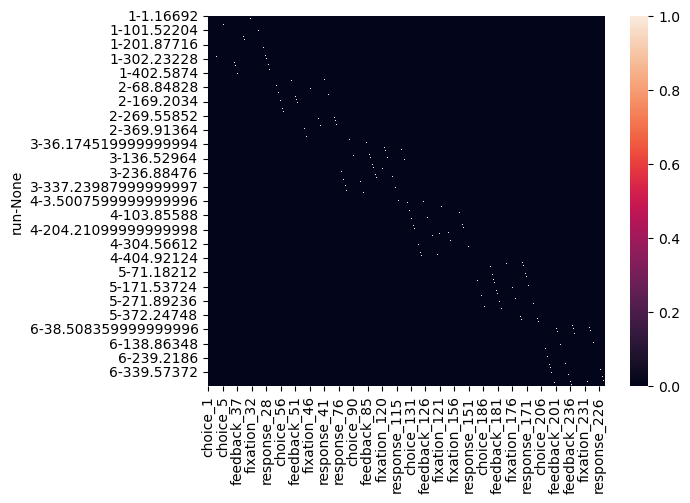

In [42]:
sns.heatmap(dm)

In [57]:
run = 1
dm1 = make_first_level_design_matrix(frametimes, onsets.loc[run], hrf_model='fir', oversampling=100.,
                                        drift_order=0,
                                        drift_model=None).drop('constant', axis=1)

In [64]:
onsets.loc[run]

,onset,duration,trial_type
run,,,
1,2.33384,0.6,choice_1
1,7.00152,0.6,feedback_1
1,11.66920,0.6,choice_2
1,16.33688,0.6,feedback_2
1,21.00456,0.6,choice_3
...,...,...,...
1,417.75736,0.6,feedback_38
1,420.09120,0.6,choice_39
1,427.09272,0.6,feedback_39


In [59]:
dm1 /= dm1.max()
dm1[dm1 < 1.0] = 0.0

In [65]:
dm1.sum(axis=0)

choice_1_delay_0      1.0
choice_10_delay_0     1.0
choice_11_delay_0     1.0
choice_12_delay_0     1.0
choice_13_delay_0     1.0
                     ... 
feedback_5_delay_0    1.0
feedback_6_delay_0    1.0
feedback_7_delay_0    1.0
feedback_8_delay_0    1.0
feedback_9_delay_0    1.0
Length: 80, dtype: float64

<Axes: ylabel='run-None'>

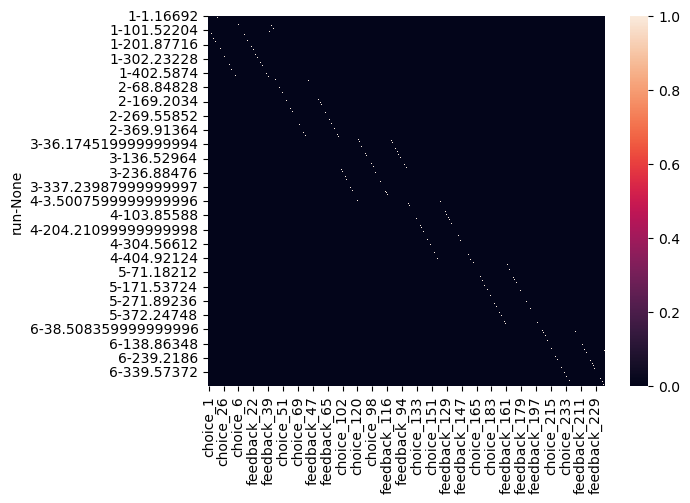

In [63]:
sns.heatmap(dm.sort_index())